# Atividade Keras — Rede Neural Multi Camadas
**Dataset:** `credito.csv`

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1780920560.102172   16203 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780920561.592532   16203 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780920565.111091   16203 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Carregamento e visualização dos dados

In [2]:
df = pd.read_csv('credito.csv')
print('Shape:', df.shape)
df.head()

Shape: (690, 16)


,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1,1,Industrials,White,1.25,1,1,1,0,ByBirth,202,0,1
1,0,58.67,4.460,1,1,Materials,Black,3.04,1,1,6,0,ByBirth,43,560,1
2,0,24.50,0.500,1,1,Materials,Black,1.50,1,0,0,0,ByBirth,280,824,1
3,1,27.83,1.540,1,1,Industrials,White,3.75,1,1,5,1,ByBirth,100,3,1
4,1,20.17,5.625,1,1,Industrials,White,1.71,1,0,0,0,ByOtherMeans,120,0,1


In [3]:
print('Tipos de dados:')
print(df.dtypes)
print('\nDistribuição do target (Approved):')
print(df['Approved'].value_counts())

Tipos de dados:
Gender              int64
Age               float64
Debt              float64
Married             int64
BankCustomer        int64
Industry              str
Ethnicity             str
YearsEmployed     float64
PriorDefault        int64
Employed            int64
CreditScore         int64
DriversLicense      int64
Citizen               str
ZipCode             int64
Income              int64
Approved            int64
dtype: object

Distribuição do target (Approved):
Approved
0    383
1    307
Name: count, dtype: int64


## 3. Pré-processamento

### 3.1 Separar amostra de teste ANTES de qualquer transformação

In [4]:
# Amostra de 5% separada antes de qualquer transformação (conforme requisito)
df_amostra_teste = df.sample(frac=0.05, random_state=42)
print(f'Amostra de teste separada: {len(df_amostra_teste)} registros')

Amostra de teste separada: 34 registros


### 3.2 Encoding das colunas categóricas

In [5]:
df_proc = pd.get_dummies(df, columns=['Industry', 'Ethnicity', 'Citizen'], drop_first=True)

# Converter colunas booleanas para int
bool_cols = df_proc.select_dtypes(include='bool').columns
df_proc[bool_cols] = df_proc[bool_cols].astype(int)

print('Colunas após encoding:', df_proc.columns.tolist())

Colunas após encoding: ['Gender', 'Age', 'Debt', 'Married', 'BankCustomer', 'YearsEmployed', 'PriorDefault', 'Employed', 'CreditScore', 'DriversLicense', 'ZipCode', 'Income', 'Approved', 'Industry_ConsumerDiscretionary', 'Industry_ConsumerStaples', 'Industry_Education', 'Industry_Energy', 'Industry_Financials', 'Industry_Healthcare', 'Industry_Industrials', 'Industry_InformationTechnology', 'Industry_Materials', 'Industry_Real Estate', 'Industry_Research', 'Industry_Transport', 'Industry_Utilities', 'Ethnicity_Black', 'Ethnicity_Latino', 'Ethnicity_Other', 'Ethnicity_White', 'Citizen_ByOtherMeans', 'Citizen_Temporary']


### 3.3 Separar X e y

In [6]:
X = df_proc.drop('Approved', axis=1)
y = df_proc['Approved']

# Guardar as colunas para reusar na amostra de teste
feature_columns = X.columns.tolist()
print(f'Features: {len(feature_columns)} colunas')
print(f'Target: {y.value_counts().to_dict()}')

Features: 31 colunas
Target: {0: 383, 1: 307}


### 3.4 Divisão treino / validação / teste

In [7]:
# 70% treino | 15% validação | 15% teste
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Treino:    {X_train.shape[0]} amostras')
print(f'Validação: {X_val.shape[0]} amostras')
print(f'Teste:     {X_test.shape[0]} amostras')

Treino:    483 amostras
Validação: 103 amostras
Teste:     104 amostras


### 3.5 Normalização (StandardScaler)

In [8]:
scaler = StandardScaler()

# fit apenas no treino para evitar data leakage
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

## 4. EarlyStopping

Configurado com `patience=20` — o treinamento para se em mais de 20 épocas o erro não diminuir.

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

## 5. Treinamento das 3 redes

---
### Rede 1 — Simples (2 camadas, ReLU, SGD)

In [10]:
model1 = Sequential(name='Rede_1_Simples')
model1.add(Dense(units=16, activation='relu'))
model1.add(Dense(units=8,  activation='relu'))
model1.add(Dense(units=1,  activation='sigmoid'))

model1.compile(loss='binary_crossentropy', optimizer='SGD')

history1 = model1.fit(
    X_train, y_train,
    epochs=200,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)
print('Rede 1 treinada — épocas executadas:', len(history1.history['loss']))

E0000 00:00:1780921175.595053   16203 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 90: early stopping
Restoring model weights from the end of the best epoch: 70.
Rede 1 treinada — épocas executadas: 90


---
### Rede 2 — Profunda (3 camadas, ReLU, Adam)

In [11]:
model2 = Sequential(name='Rede_2_Profunda')
model2.add(Dense(units=64, activation='relu'))
model2.add(Dense(units=32, activation='relu'))
model2.add(Dense(units=16, activation='relu'))
model2.add(Dense(units=1,  activation='sigmoid'))

model2.compile(loss='binary_crossentropy', optimizer='adam')

history2 = model2.fit(
    X_train, y_train,
    epochs=200,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)
print('Rede 2 treinada — épocas executadas:', len(history2.history['loss']))

Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 1.
Rede 2 treinada — épocas executadas: 20


---
### Rede 3 — Ativação Tanh (2 camadas, Tanh, Adam)

In [12]:
model3 = Sequential(name='Rede_3_Tanh')
model3.add(Dense(units=32, activation='tanh'))
model3.add(Dense(units=16, activation='tanh'))
model3.add(Dense(units=1,  activation='sigmoid'))

model3.compile(loss='binary_crossentropy', optimizer='adam')

history3 = model3.fit(
    X_train, y_train,
    epochs=200,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)
print('Rede 3 treinada — épocas executadas:', len(history3.history['loss']))

Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 1.
Rede 3 treinada — épocas executadas: 20


## 6. Curvas de Loss

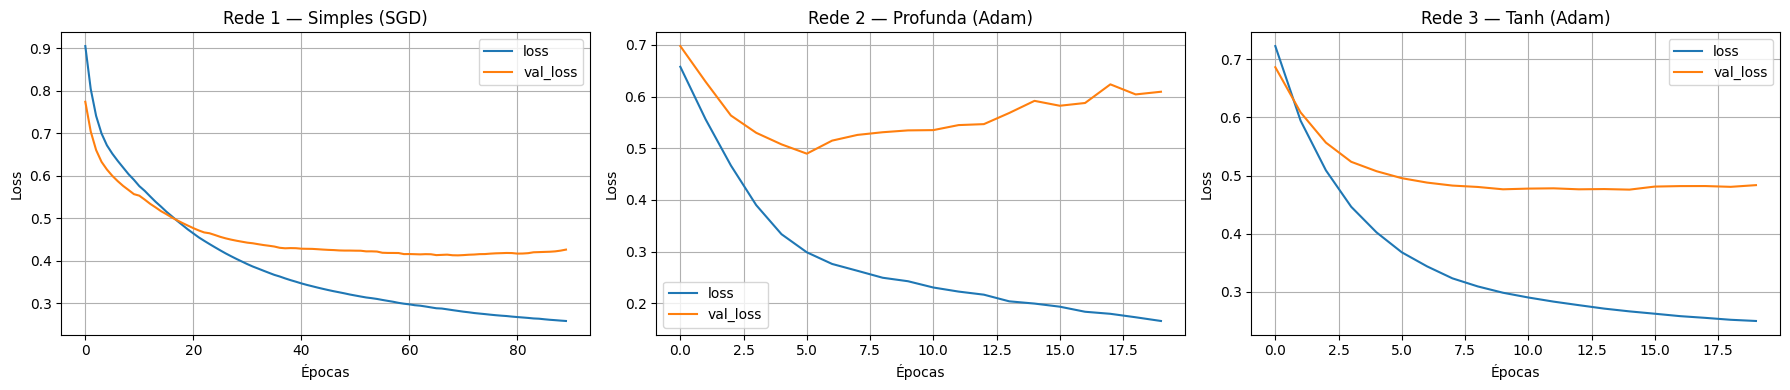

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, history, titulo in zip(axes,
                               [history1, history2, history3],
                               ['Rede 1 — Simples (SGD)', 'Rede 2 — Profunda (Adam)', 'Rede 3 — Tanh (Adam)']):
    pd.DataFrame(history.history).plot(ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel('Épocas')
    ax.set_ylabel('Loss')
    ax.grid(True)

plt.tight_layout()
plt.show()

## 7. Avaliação — Acurácia, Precisão e Recall

In [14]:
resultados = {}

def avaliar(model, nome):
    preds = (model.predict(X_test, verbose=0) > 0.5).astype(int)
    report = classification_report(y_test, preds, target_names=['Reprovado (0)', 'Aprovado (1)'], output_dict=True)
    resultados[nome] = {
        'Acurácia':  round(report['accuracy'], 4),
        'Precisão':  round(report['Aprovado (1)']['precision'], 4),
        'Recall':    round(report['Aprovado (1)']['recall'], 4),
        'F1-score':  round(report['Aprovado (1)']['f1-score'], 4),
    }
    print(f'\n=== {nome} ===')
    print(classification_report(y_test, preds, target_names=['Reprovado (0)', 'Aprovado (1)']))

avaliar(model1, 'Rede 1 — Simples (SGD)')
avaliar(model2, 'Rede 2 — Profunda (Adam)')
avaliar(model3, 'Rede 3 — Tanh (Adam)')


=== Rede 1 — Simples (SGD) ===
               precision    recall  f1-score   support

Reprovado (0)       0.87      0.84      0.86        57
 Aprovado (1)       0.82      0.85      0.83        47

     accuracy                           0.85       104
    macro avg       0.84      0.85      0.85       104
 weighted avg       0.85      0.85      0.85       104


=== Rede 2 — Profunda (Adam) ===
               precision    recall  f1-score   support

Reprovado (0)       0.65      0.93      0.77        57
 Aprovado (1)       0.83      0.40      0.54        47

     accuracy                           0.69       104
    macro avg       0.74      0.67      0.66       104
 weighted avg       0.73      0.69      0.67       104


=== Rede 3 — Tanh (Adam) ===
               precision    recall  f1-score   support

Reprovado (0)       0.73      0.67      0.70        57
 Aprovado (1)       0.63      0.70      0.67        47

     accuracy                           0.68       104
    macro avg   

### 7.1 Tabela comparativa

In [15]:
df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.sort_values('Recall', ascending=False)
print('Comparativo das 3 redes (ordenado por Recall):')
df_resultados

Comparativo das 3 redes (ordenado por Recall):


,Acurácia,Precisão,Recall,F1-score
Rede 1 — Simples (SGD),0.8462,0.8163,0.8511,0.8333
Rede 3 — Tanh (Adam),0.6827,0.6346,0.7021,0.6667
Rede 2 — Profunda (Adam),0.6923,0.8261,0.4043,0.5429


### 7.2 Melhor rede (maior Recall)

In [16]:
melhor_nome = df_resultados['Recall'].idxmax()
print(f'Rede com maior Recall: {melhor_nome}')
print(f'Recall: {df_resultados.loc[melhor_nome, "Recall"]}')

# Seleciona o objeto do melhor modelo
mapa_modelos = {
    'Rede 1 — Simples (SGD)':   model1,
    'Rede 2 — Profunda (Adam)':  model2,
    'Rede 3 — Tanh (Adam)':      model3,
}
melhor_modelo = mapa_modelos[melhor_nome]

Rede com maior Recall: Rede 1 — Simples (SGD)
Recall: 0.8511


## 8. Salvando os pesos do melhor modelo

Conforme a [documentação do Keras](https://keras.io/api/models/model_saving_apis/weights_saving_and_loading/).

In [17]:
melhor_modelo.save_weights('melhor_modelo_credito.weights.h5')
print('Pesos salvos em: melhor_modelo_credito.weights.h5')

Pesos salvos em: melhor_modelo_credito.weights.h5


### 8.1 Verificação — carregando os pesos e refazendo predição

In [18]:
melhor_modelo.load_weights('melhor_modelo_credito.weights.h5')

preds_verificacao = (melhor_modelo.predict(X_test, verbose=0) > 0.5).astype(int)
print('Pesos carregados com sucesso. Predições após reload:')
print(classification_report(y_test, preds_verificacao, target_names=['Reprovado (0)', 'Aprovado (1)']))

Pesos carregados com sucesso. Predições após reload:
               precision    recall  f1-score   support

Reprovado (0)       0.87      0.84      0.86        57
 Aprovado (1)       0.82      0.85      0.83        47

     accuracy                           0.85       104
    macro avg       0.84      0.85      0.85       104
 weighted avg       0.85      0.85      0.85       104



## 9. Amostra de teste — Real vs Predito

Tabela com a diferença entre classes reais e as respostas do melhor modelo.

In [19]:
# Aplicar o mesmo encoding e scaler na amostra separada no início
df_amostra_proc = pd.get_dummies(df_amostra_teste, columns=['Industry', 'Ethnicity', 'Citizen'], drop_first=True)

bool_cols_amostra = df_amostra_proc.select_dtypes(include='bool').columns
df_amostra_proc[bool_cols_amostra] = df_amostra_proc[bool_cols_amostra].astype(int)

# Garantir as mesmas colunas (na mesma ordem) usadas no treino
X_amostra = df_amostra_proc.reindex(columns=feature_columns, fill_value=0)
y_amostra_real = df_amostra_teste['Approved'].values

# Normalizar com o mesmo scaler do treino
X_amostra_scaled = scaler.transform(X_amostra)

# Predição
preds_amostra = (melhor_modelo.predict(X_amostra_scaled, verbose=0) > 0.5).astype(int).flatten()

# Montar DataFrame comparativo
df_comparativo = pd.DataFrame({
    'Real':    y_amostra_real,
    'Predito': preds_amostra,
})
df_comparativo['Correto'] = df_comparativo['Real'] == df_comparativo['Predito']
df_comparativo['Resultado'] = df_comparativo['Correto'].map({True: '✔ Acertou', False: '✘ Errou'})
df_comparativo.index = df_amostra_teste.index

print(df_comparativo)
print(f'\nTotal de acertos: {df_comparativo["Correto"].sum()} / {len(df_comparativo)}')

     Real  Predito  Correto  Resultado
286     0        0     True  ✔ Acertou
511     1        0    False    ✘ Errou
257     0        0     True  ✔ Acertou
336     0        0     True  ✔ Acertou
318     1        0    False    ✘ Errou
211     1        0    False    ✘ Errou
624     0        0     True  ✔ Acertou
176     1        0    False    ✘ Errou
462     0        0     True  ✔ Acertou
256     0        0     True  ✔ Acertou
662     0        0     True  ✔ Acertou
165     1        1     True  ✔ Acertou
621     1        0    False    ✘ Errou
78      0        1    False    ✘ Errou
676     0        0     True  ✔ Acertou
497     1        1     True  ✔ Acertou
681     0        0     True  ✔ Acertou
294     0        0     True  ✔ Acertou
645     0        0     True  ✔ Acertou
396     0        0     True  ✔ Acertou
355     0        0     True  ✔ Acertou
334     0        0     True  ✔ Acertou
289     0        0     True  ✔ Acertou
572     1        1     True  ✔ Acertou
281     0        0     Tr

### 9.1 Justificativa do Recall

In [20]:
from sklearn.metrics import classification_report as cr

print('=== Relatório sobre a amostra de teste ===')
print(cr(y_amostra_real, preds_amostra, target_names=['Reprovado (0)', 'Aprovado (1)'], zero_division=0))

print(f'\nO melhor modelo foi: {melhor_nome}')
print(f'Recall na classe Aprovado (1) no conjunto de teste: {df_resultados.loc[melhor_nome, "Recall"]}')
print(f'\nParâmetros da rede com maior recall:')
melhor_modelo.summary()

=== Relatório sobre a amostra de teste ===
               precision    recall  f1-score   support

Reprovado (0)       0.79      0.90      0.84        21
 Aprovado (1)       0.80      0.62      0.70        13

     accuracy                           0.79        34
    macro avg       0.80      0.76      0.77        34
 weighted avg       0.79      0.79      0.79        34


O melhor modelo foi: Rede 1 — Simples (SGD)
Recall na classe Aprovado (1) no conjunto de teste: 0.8511

Parâmetros da rede com maior recall:


Model: "Rede_1_Simples"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 659 (2.58 KB)

 Trainable params: 657 (2.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)